# Cost algorithm research

This notebook will detail the research of the performance of out cost based task assignment algorithm.
We will explore different scenarios and simulation parameters to astablish its optimal operating conditions and compare performance with more basic FIFO based algorithms.

Simulation constant parameters:
 - Simulration seeds: 5
 - Field size: 1000m * 1000m
 - Algorithms:
    - FIFO
    - FIFO with priority
    - FIFO with preemtion
    - COST


Base simulation parameters:
 - Drones: 10
 - MBS: 3
 - Priority leves:
    - High: 1
    - Middle: 2
    - Low: 3
 - Task priority percentange:
    1. 2
    2. 5
    3. 3
 - Task limit: 100
 - Drone comm range: 300m
 - Task duration: 30s
 - Task expiration by priority:
    1. 30s
    2. 120s
    3. 300s
 - Simulation time limit: 1000s
 - Drone speed: 25m/s
 - MBS speed: 20m/s
 - Task generation: every 15s
 - Drone task halt cost by priority:
    1. 1000
    2. 500
    3. 100
 - Drone Energy cost multiplier: 0.5
 - MBS halt group size weight: 100
 - MBS realocation multiplier: 1


Research avenues:
    TBD

In [1]:
from sweep_runner import setup_environment
setup_environment()


opp_env loaded from cache (.opp_env_vars.json):
  INET_ROOT=/home/opp_env/default_workspace/inet-4.5.4
  OMNETPP_ROOT=/home/opp_env/default_workspace/omnetpp-6.3.0
  OMNETPP_VERSION=6.3.0
  OMNETPP_RELEASE=omnetpp-6.3.0
  OMNETPP_IMAGE_PATH=/home/opp_env/default_workspace/omnetpp-6.3.0/images:/home/opp_env/default_wo...
  OPP_ENV_VERSION=0.35.0.251114
  PATH=/home/opp_env/default_workspace/inet-4.5.4/bin:/home/opp_env/default_workspac...
  PYTHONPATH=/home/opp_env/default_workspace/inet-4.5.4/python:/home/opp_env/default_works...
  QT_PLUGIN_PATH=/nix/store/8qs879yx84gng0yljdybwi4fbbgg3dyy-qtbase-6.9.0/lib/qt-6/plugins:/ni...
  BUILD_MODES=release debug


{'INET_ROOT': '/home/opp_env/default_workspace/inet-4.5.4',
 'OMNETPP_ROOT': '/home/opp_env/default_workspace/omnetpp-6.3.0',
 'OMNETPP_VERSION': '6.3.0',
 'OMNETPP_RELEASE': 'omnetpp-6.3.0',
 'OMNETPP_IMAGE_PATH': '/home/opp_env/default_workspace/omnetpp-6.3.0/images:/home/opp_env/default_workspace/inet-4.5.4/images',
 'OPP_ENV_VERSION': '0.35.0.251114',
 'PATH': '/home/opp_env/default_workspace/inet-4.5.4/bin:/home/opp_env/default_workspace/omnetpp-6.3.0/bin:/nix/store/cvm20cv2y6p8rik02wvyzx2w76j5wilc-lndir-1.0.5/bin:/nix/store/czj4c9kniwgnniv5w7rjqr3mkvkcymfz-wayland-scanner-1.23.1-bin/bin:/nix/store/8w718rm43x7z73xhw9d6vh8s4snrq67h-python3-3.12.10/bin:/nix/store/sdqvwr8gc74ms9cgf56yvy409xvl8hsf-gettext-0.22.5/bin:/nix/store/2jc1jmzis19adawjwhl8qhdvh7vlbk0q-patchelf-0.15.0/bin:/nix/store/fmysfy9gl5d59yir4fksi29wz10maljg-clang-wrapper-19.1.7/bin:/nix/store/zmk3gqm6sxgar8b84sz66wbs7kx4v2gi-clang-19.1.7/bin:/nix/store/303islqk386z1w2g1ngvxnkl4glfpgrs-glibc-2.40-66-bin/bin:/nix/store/87

In [2]:
from sweep_runner import run_sweep

# ---- Sim constants (single point; sweep dims are 1-valued to satisfy the
# runner's 2-D requirement). All four allocators run on the same scenario.
algorithms = ["FIFO", "FIFO_PRIO", "FIFO_PREEMPT", "COST"]
seeds = 5  # repetitions per algorithm (each uses a different OMNeT++ runnumber)

# Base scenario -- matches the bullets at the top of this notebook.
numDrones = 10
numMbs    = 3

# Task generator / SLA
task_limit               = 100
task_generation_interval = "15s"          # fixed 15s cadence
task_duration            = "30s"
priority_levels          = 3
priority_weights         = '"2 5 3"'       # pri1:pri2:pri3 = 2:5:3 (mid-heavy)
task_deadline_weights    = '"30 120 300"'  # HIGH 30s, MID 120s, LOW 300s

# COST tunables (FIFO* ignore these)
cost_energy_weight          = 0.5
cost_halt_priority_weight   = 100.0            # scalar fallback (unused when the table is set)
cost_halt_priority_weights  = '"1000 500 100"' # per-class halt cost
cost_halt_group_size_weight = 100.0            # +cost per drone in the preempted group
cost_mbs_relocation_weight  = 1.0              # per metre, MBS shift

# Global / non-mainNode params -- pass with full ini pattern; the runner
# leaves them alone (no `*.mainNode.app[0].` prefix prepended).
extra_overrides = {
    # mainNode.app[0] tunables (bare names get the prefix automatically)
    "taskLimit":                task_limit,
    "taskGenerationInterval":   task_generation_interval,
    "taskDuration":             task_duration,
    "priorityLevels":           priority_levels,
    "priorityWeights":          priority_weights,
    "taskDeadlineWeights":      task_deadline_weights,
    "costEnergyWeight":         cost_energy_weight,
    "costHaltPriorityWeight":   cost_halt_priority_weight,
    "costHaltPriorityWeights":  cost_halt_priority_weights,
    "costHaltGroupSizeWeight":  cost_halt_group_size_weight,
    "costMbsRelocationWeight":  cost_mbs_relocation_weight,
    # Global / mobility / comms -- full ini patterns, untouched by the runner
    "sim-time-limit":           "1000s",
    "**.drone_comm_range":      "150m",
    "*.drone[*].app[0].speed":  "25mps",
    "*.mbs[*].app[0].speed":    "20mps",
}

sweep_dir = run_sweep(
    sweep_params={
        "*.numDrones": [numDrones],   # single-valued -> degenerate sweep dim
        "*.numMbs":    [numMbs],
    },
    extra_overrides=extra_overrides,
    repetitions=seeds,
    algorithm=algorithms,
    label="algo_compare_base",
)
print("Sweep finished:", sweep_dir)


18:49:11 INFO Sweep 'algo_compare_base/FIFO' starting -- output dir: /home/opp_env/default_workspace/UavSwarmTA/sim_data/algo_compare_base/FIFO
18:49:11 INFO Sweep dimensions: {'*.numDrones': [10], '*.numMbs': [3]}
18:49:11 INFO Repetitions per cell: 5
18:49:11 INFO Extra (constant) overrides: {'taskLimit': 100, 'taskGenerationInterval': '15s', 'taskDuration': '30s', 'priorityLevels': 3, 'priorityWeights': '"2 5 3"', 'taskDeadlineWeights': '"30 120 300"', 'costEnergyWeight': 0.5, 'costHaltPriorityWeight': 100.0, 'costHaltPriorityWeights': '"1000 500 100"', 'costHaltGroupSizeWeight': 100.0, 'costMbsRelocationWeight': 1.0, 'sim-time-limit': '1000s', '**.drone_comm_range': '150m', '*.drone[*].app[0].speed': '25mps', '*.mbs[*].app[0].speed': '20mps', 'algorithmType': '"FIFO"'}
18:49:11 INFO Total cells: 1 (5 runs)
18:49:11 INFO [cell] numDrones=10 | numMbs=3
18:49:11 INFO   -> run 1/5 (rep=0) starting
18:49:11 INFO      ok (0.19s) -> numDrones=10/numMbs=3/rep0-tasks.csv
18:49:11 INFO   -> 

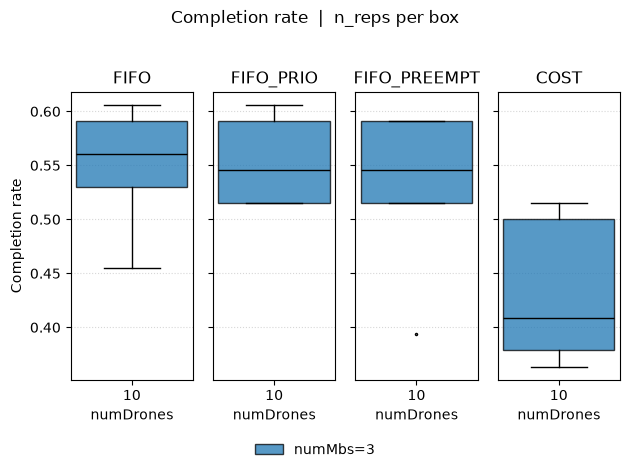

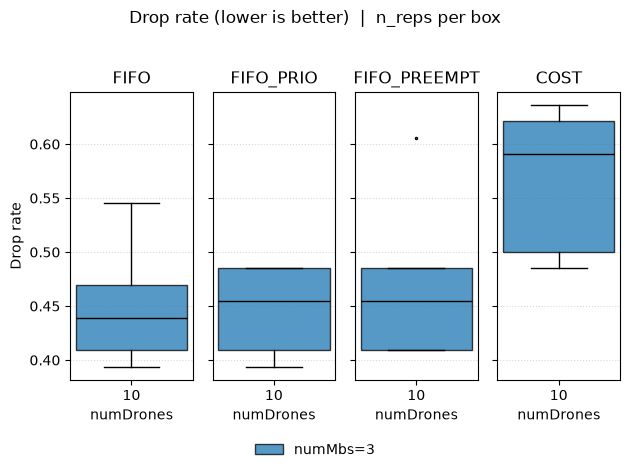

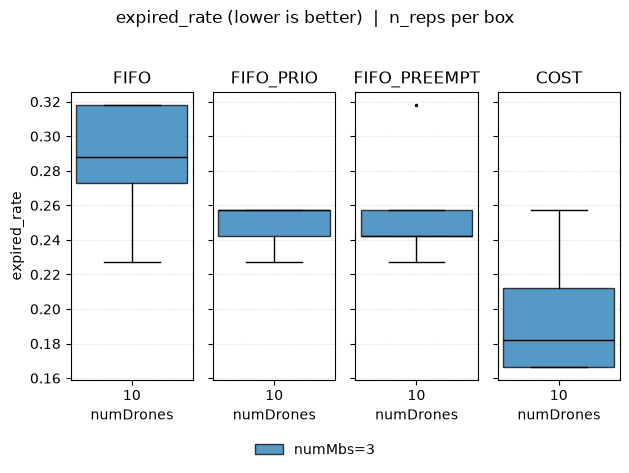

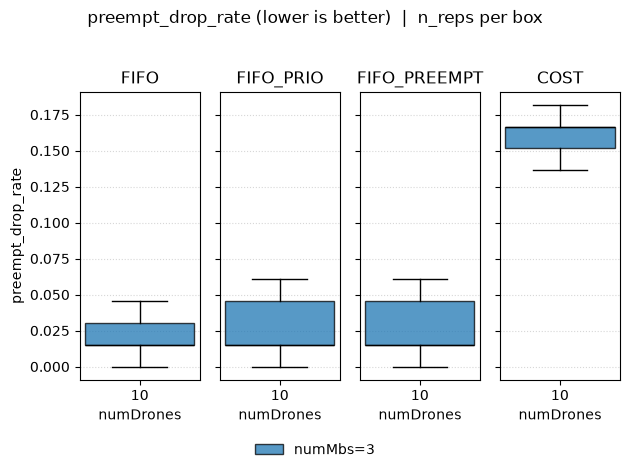

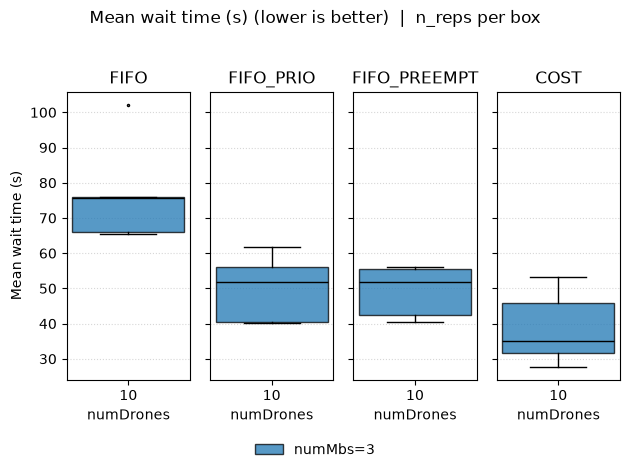

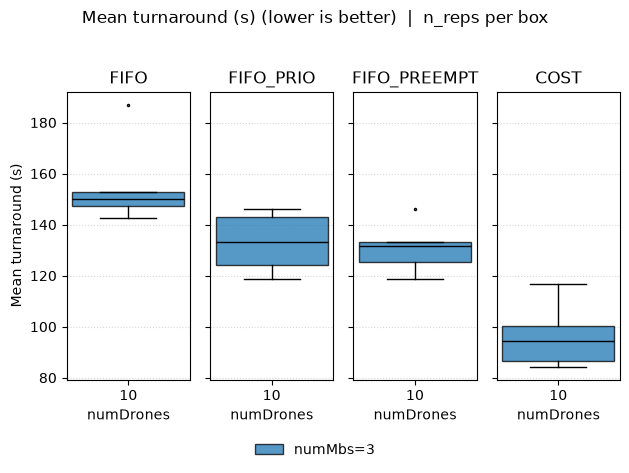

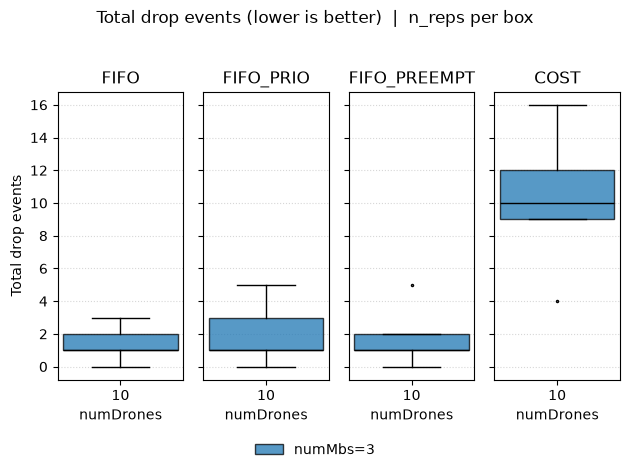

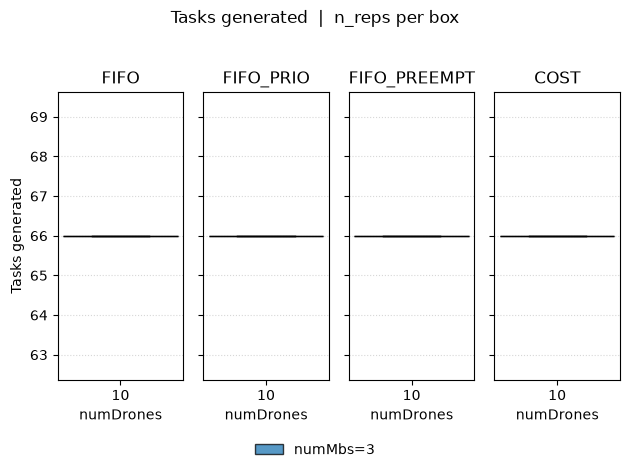

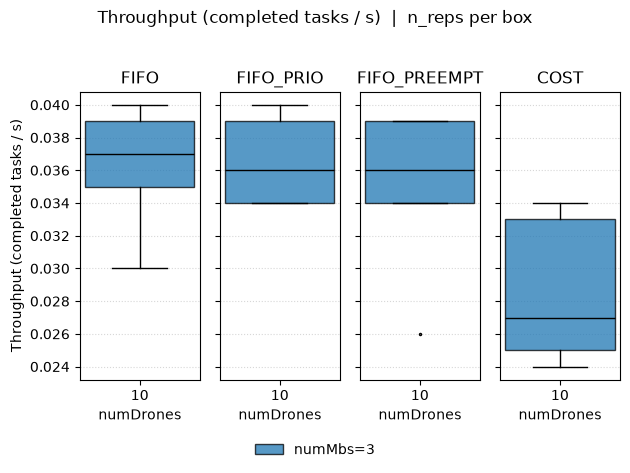

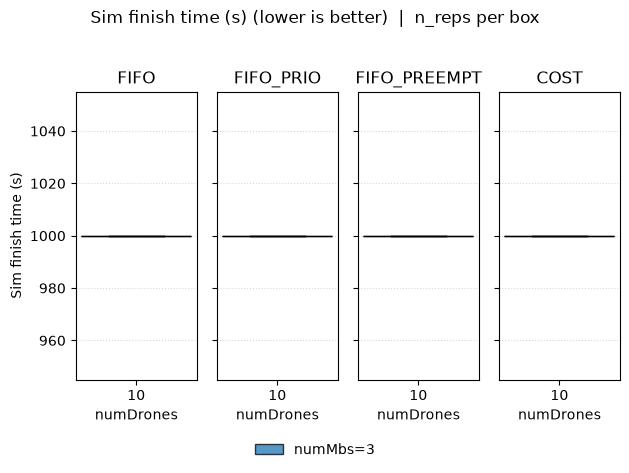

In [3]:
from sweep_plotter import plot_sweep

plot_kind = "box"   # "box" for distribution view, "line" for overlay trends

for metric in [
    "completion_rate",
    "drop_rate",
    "expired_rate",       # EXPIRED only -- queue-wait SLA misses
    "preempt_drop_rate",  # DROPPED only -- preemption / MBS reloc / failure
    "mean_wait",
    "mean_turnaround",
    "total_drops",
    "n_tasks",
    "throughput",
    "sim_finish_time"
]:
    fig, df = plot_sweep(sweep_dir, metric=metric, kind=plot_kind)


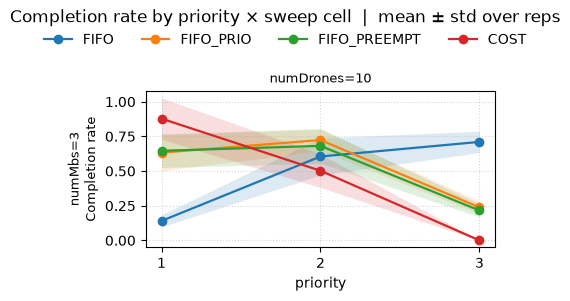

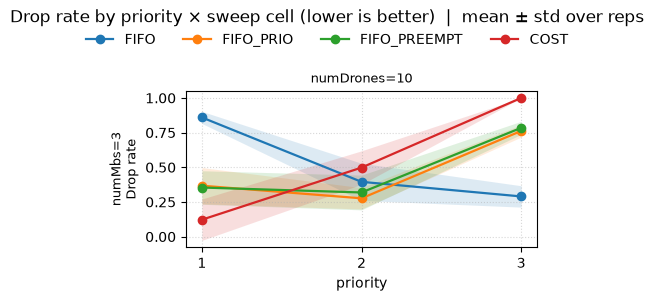

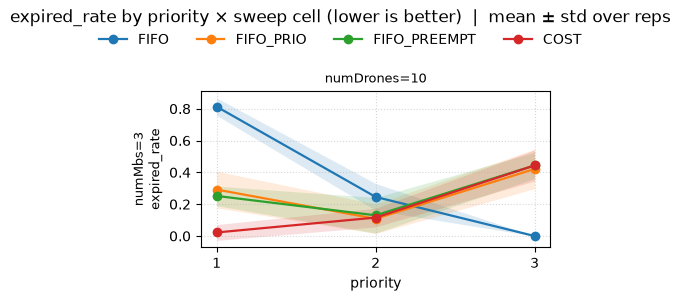

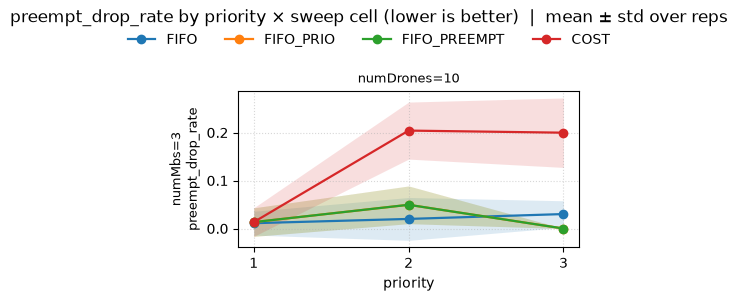

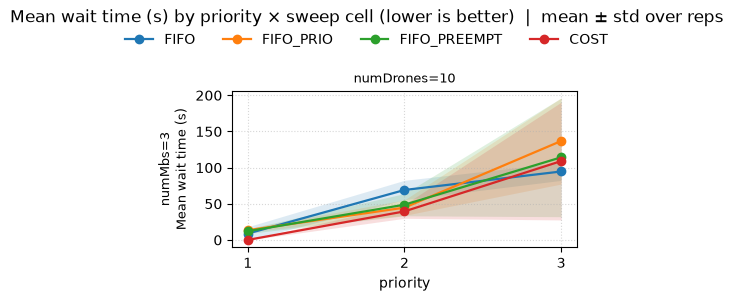

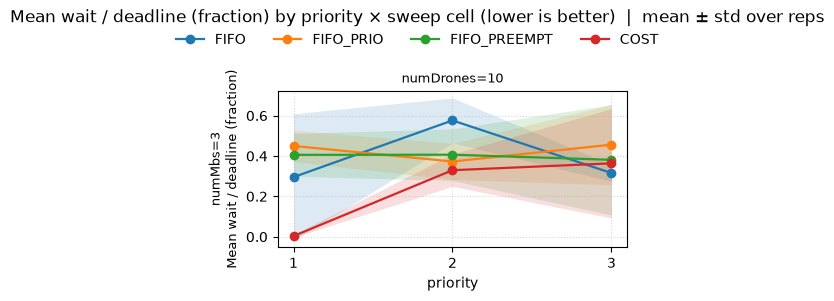

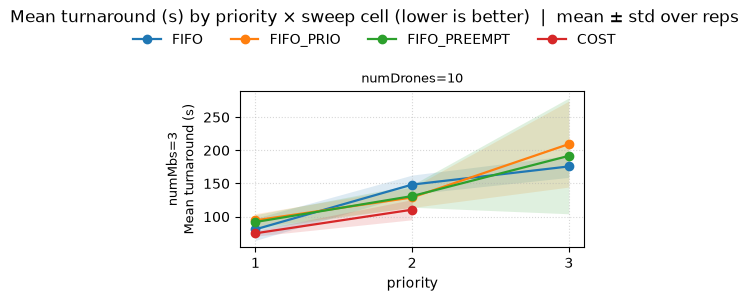

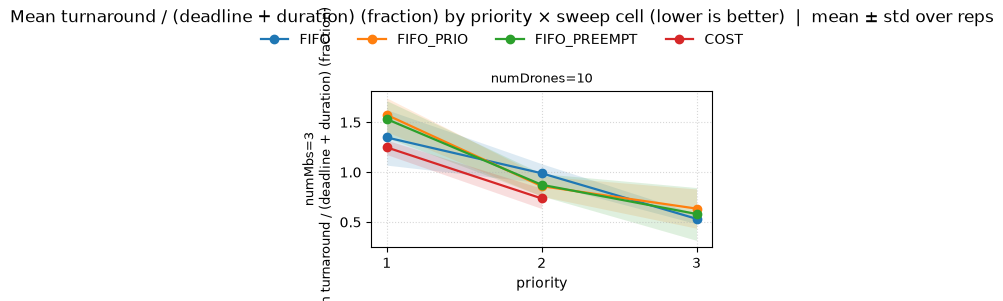

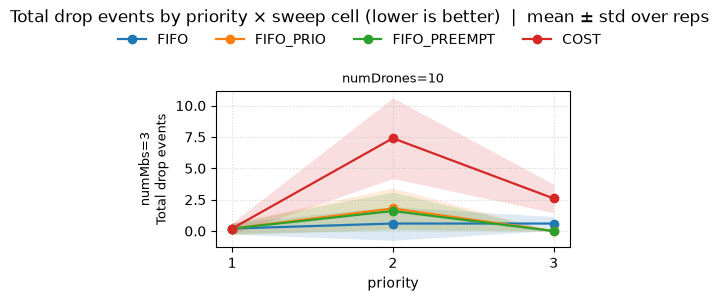

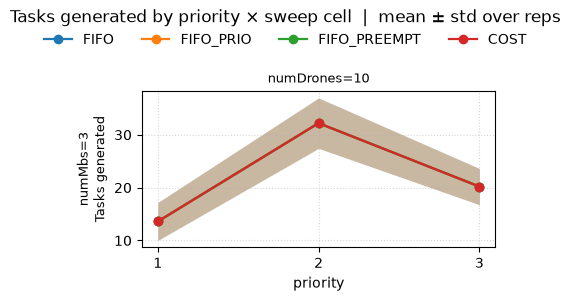

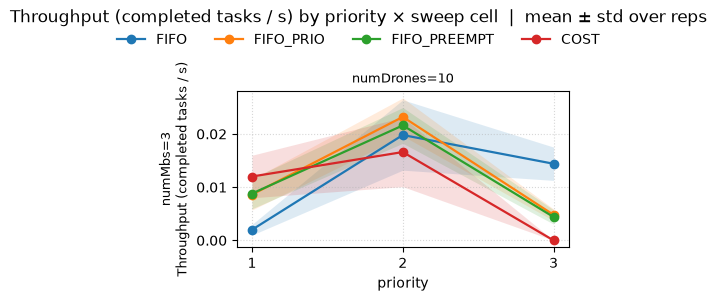

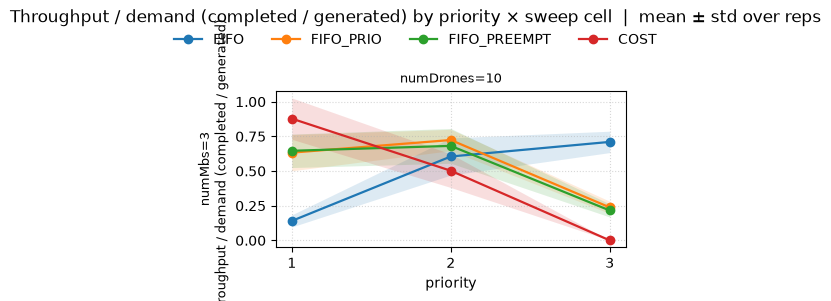

In [4]:
from sweep_plotter import plot_by_priority

prio_kind = "grid"   # "grid" for per-cell view, "pooled" for the summary

for metric in [
    "completion_rate",
    "drop_rate",
    "expired_rate",       # SLA-miss rate per priority class
    "preempt_drop_rate",  # preemption / drone-failure rate per priority class
    "mean_wait",
    "mean_wait_norm",        # mean_wait / deadline_for_priority
    "mean_turnaround",
    "mean_turnaround_norm",  # mean_turnaround / (deadline + taskDuration)
    "total_drops",
    "n_tasks",
    "throughput",
    "throughput_norm",       # served fraction of per-class demand
]:
    fig, df_prio = plot_by_priority(sweep_dir, metric=metric, kind=prio_kind)